In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import numpy as np

# Check GPU

In [125]:
device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')
device

device(type='cuda', index=0)

# Model

In [126]:
def Net(device):
  net = nn.Sequential(
      nn.Linear(20,100),
      nn.ReLU(),
      nn.Linear(100,500),
      nn.ReLU(),
      nn.Linear(500,50),
      nn.ReLU(),
      nn.Linear(50,2)
  )

  net.to(device)

  return net

net_gpu = Net(device = device)
net_cpu = Net(device = 'cpu')

In [127]:
net_gpu

Sequential(
  (0): Linear(in_features=20, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=500, bias=True)
  (3): ReLU()
  (4): Linear(in_features=500, out_features=50, bias=True)
  (5): ReLU()
  (6): Linear(in_features=50, out_features=2, bias=True)
)

In [128]:
net_cpu

Sequential(
  (0): Linear(in_features=20, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=500, bias=True)
  (3): ReLU()
  (4): Linear(in_features=500, out_features=50, bias=True)
  (5): ReLU()
  (6): Linear(in_features=50, out_features=2, bias=True)
)

# Data

In [129]:
X = np.random.randn(1000,20)
y = np.random.randint(2, size = (1, 1000))

X = torch.tensor(X, dtype = torch.float)
y = torch.tensor(y, dtype = torch.long)

X.shape, y.shape

(torch.Size([1000, 20]), torch.Size([1, 1000]))

# Send Objects to GPU

In [130]:
X = X.to(device)
y = y.to(device)

We can also create data directly on given processing unit

In [131]:
data_gpu = torch.randn(1000,20, device = device)
data_cpu = torch.randn(1000,20, device = 'cpu')

data_gpu.device, data_cpu.device

(device(type='cuda', index=0), device(type='cpu'))

# Run

In [132]:
output_gpu = net_gpu(data_gpu)
output_gpu.device

device(type='cuda', index=0)

In [133]:
output_cpu = net_cpu(data_cpu)
output_cpu.device

device(type='cpu')

# Plot

Before plotting we need to move objects from cpu to gpu

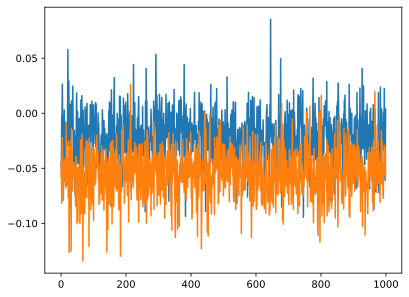

In [134]:
output_gpu = output_gpu.to('cpu')
plt.plot(output_gpu.detach())
plt.show()

If data is on cpu we don't need to do antyhing

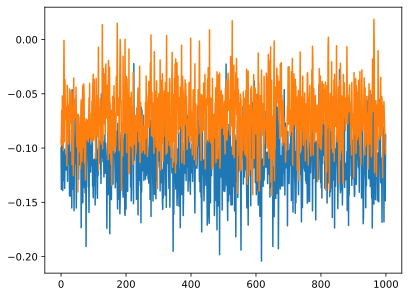

In [135]:
plt.plot(output_cpu.detach())
plt.show()

# Experiment: Computation Time

## Test Just Computation Time

In [136]:
start_time = time.process_time()

net_cpu(data_cpu)

cpu_time = 1000 * (time.process_time() - start_time)
cpu_time

12.638981000009153

In [137]:
start_time = time.process_time()

net_gpu(data_gpu)

gpu_time = 1000 * (time.process_time() - start_time)
gpu_time

1.829522999969413

In [138]:
perc = (cpu_time / gpu_time) * 100
print(f'GPU is faster than CPU by {perc:1f}%')

GPU is faster than CPU by 690.834770%


## Test Computation + Moving to GPU time

In [139]:
start_time = time.process_time()

net = net_cpu.to(device)
data_gpu = data_cpu.to(device)
net(data_gpu)

gpu_move_time = 1000 * (time.process_time() - start_time)
gpu_move_time

2.5760639999816703

In [140]:
perc = (cpu_time / gpu_move_time) * 100
print(f'GPU is faster than CPU by {perc:.1f}% when including moving to GPU')

GPU is faster than CPU by 490.6% when including moving to GPU


## Plot

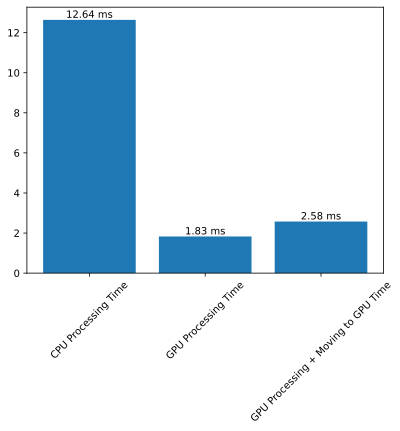

In [141]:
times = [cpu_time, gpu_time, gpu_move_time]
labels = ['CPU Processing Time', 'GPU Processing Time', 'GPU Processing + Moving to GPU Time']
x = range(len(times))
plt.bar(x, times)
plt.xticks(x, labels, rotation = 45)
for x, y in zip(x,times):
  plt.text(x, y, f'{y:.2f} ms', ha = 'center', va = 'bottom')
plt.show()

The difference is big. However, in ms it's just ~10-12 ms absolutely. That's why it doesn't make sense to train on GPU unless we have some serious model going on.

# Full Training

## Data

In [142]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
from IPython import display

display.set_matplotlib_formats('svg')

/tmp/ipython-input-4172365778.py:9: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [143]:
import seaborn as sns

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [144]:
data = torch.tensor(iris.iloc[:,:4].values).float()
data[:5,:]

tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000]])

In [145]:
labels = torch.zeros(iris.shape[0], dtype = torch.long)
labels[iris.species == 'setosa'] = 0
labels[iris.species == 'versicolor'] = 1
labels[iris.species == 'virginica'] = 2
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

## Arch

In [146]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ANN(nn.Module):
  def __init__(self, nUnits, nLayers):
    super().__init__()
    self.nLayers = nLayers

    self.layers = nn.ModuleDict()

    self.layers['input'] = nn.Linear(4, nUnits)

    for i in range(nLayers):
      self.layers[f'hidden_{i}'] = nn.Linear(nUnits, nUnits)

    self.layers['output'] = nn.Linear(nUnits, 3)

  def forward(self, x):
    x = self.layers['input'](x)

    for i in range(self.nLayers):
      x = F.relu(self.layers[f'hidden_{i}'](x))

    x = self.layers['output'](x)

    return x

ann = ANN(nUnits=32, nLayers=8)
ann

ANN(
  (layers): ModuleDict(
    (input): Linear(in_features=4, out_features=32, bias=True)
    (hidden_0): Linear(in_features=32, out_features=32, bias=True)
    (hidden_1): Linear(in_features=32, out_features=32, bias=True)
    (hidden_2): Linear(in_features=32, out_features=32, bias=True)
    (hidden_3): Linear(in_features=32, out_features=32, bias=True)
    (hidden_4): Linear(in_features=32, out_features=32, bias=True)
    (hidden_5): Linear(in_features=32, out_features=32, bias=True)
    (hidden_6): Linear(in_features=32, out_features=32, bias=True)
    (hidden_7): Linear(in_features=32, out_features=32, bias=True)
    (output): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [147]:
tmp_x = torch.randn(10, 4)

y = ann(tmp_x)

print(y.shape, y)

torch.Size([10, 3]) tensor([[ 0.1438, -0.1075,  0.1110],
        [ 0.1438, -0.1074,  0.1112],
        [ 0.1438, -0.1074,  0.1112],
        [ 0.1439, -0.1074,  0.1113],
        [ 0.1440, -0.1074,  0.1113],
        [ 0.1442, -0.1072,  0.1117],
        [ 0.1441, -0.1072,  0.1116],
        [ 0.1441, -0.1073,  0.1115],
        [ 0.1439, -0.1073,  0.1114],
        [ 0.1439, -0.1073,  0.1114]], grad_fn=<AddmmBackward0>)


## Train Loop

In [148]:
def train(Model, data, labels, epochs, verbose):
  # Model.train()

  lossfn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(Model.parameters(), lr=1e-3)

  for epoch in range(epochs):
    yHat = Model(data)

    loss = lossfn(yHat, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%10==0 and verbose:
      print(f'Epoch: {epoch}, Loss: {loss}')

  # Model.eval()
  with torch.no_grad():
    preds = Model(data)
    predlabels = torch.argmax(preds, axis=1)
    acc = 100*torch.mean((predlabels == labels).float())
  nParams = sum(p.numel() for p in Model.parameters() if p.requires_grad)

  return acc, nParams

## Train GPU vs CPU Comparisong

## CPU

In [149]:
import time

In [150]:
data.device, labels.device, next(ann.parameters()).device

(device(type='cpu'), device(type='cpu'), device(type='cpu'))

In [151]:
cpu_start = time.process_time()
train(ann, data, labels, epochs=10000, verbose = False)
cpu_time = 1000 * (time.process_time() - cpu_start)

## To GPU

In [152]:
ann = ann.to(device)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

## GPU

In [153]:
ann = ann.to(device)
data = data.to(device)
labels = labels.to(device)
data.device, labels.device, next(ann.parameters()).device

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [154]:
gpu_start = time.process_time()
train(ann, data, labels, epochs=10000, verbose = False)
gpu_time = 1000 * (time.process_time() - gpu_start)

## Plot GPU vs CPU

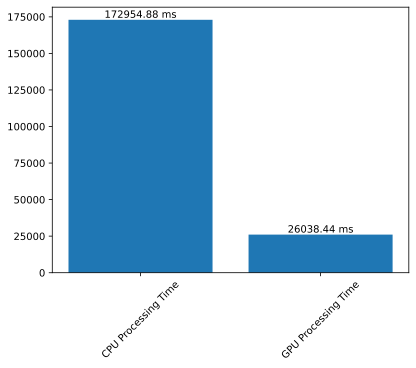

In [155]:
times = [cpu_time, gpu_time]
ticks = ['CPU Processing Time', 'GPU Processing Time']
x = range(len(times))
plt.bar(x, times)
plt.xticks(x, ticks, rotation = 45)
for x, y in zip(x,times):
  plt.text(x, y, f'{y:.2f} ms', ha = 'center', va = 'bottom')
plt.title('Single Run GPU/CPU Time Comparison')
plt.show()

## Experiment On CPU

In [166]:
numlayers = range(1,6)
numunits = np.arange(4,101,3) # units per hidden layer

# initialize output matrices
accuracies = np.zeros((len(numunits), len(numlayers)))
totalparams = np.zeros((len(numunits), len(numlayers)))

numepochs = 500

data = data.to('cpu')
labels = labels.to('cpu')

cpu_start = time.process_time()

for unitidx in range(len(numunits)):
  for layeridx in range(len(numlayers)):

    net = ANN(numunits[unitidx], numlayers[layeridx])

    acc, nParams = train(net, data = data, labels = labels, epochs = numepochs, verbose = False)

    accuracies[unitidx, layeridx] = acc

    totalparams[unitidx, layeridx] = nParams

    # print(f'Done units {numunits[unitidx]} layer {numlayers[layeridx]}')

cpu_time = 1000 * (time.process_time() - cpu_start)

## Experiment on GPU

In [167]:
# initialize output matrices
accuracies = np.zeros((len(numunits), len(numlayers)))
totalparams = np.zeros((len(numunits), len(numlayers)))

numepochs = 500

data = data.to(device)
labels = labels.to(device)

gpu_start = time.process_time()

for unitidx in range(len(numunits)):
  for layeridx in range(len(numlayers)):

    net = ANN(numunits[unitidx], numlayers[layeridx])
    net = net.to(device)

    acc, nParams = train(net, data = data, labels = labels, epochs = numepochs, verbose = False)

    accuracies[unitidx, layeridx] = acc

    totalparams[unitidx, layeridx] = nParams

    # print(f'Done units {numunits[unitidx]} layer {numlayers[layeridx]}')

gpu_time = 1000 * (time.process_time() - gpu_start)

## Plots

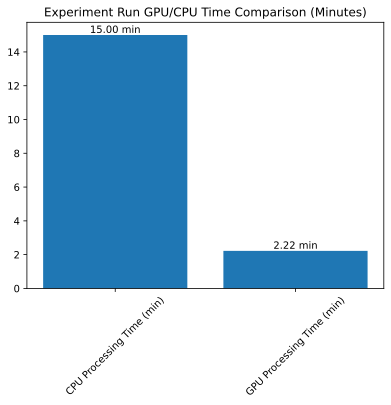

In [171]:
times = [cpu_time / 60000, gpu_time / 60000]
ticks = ['CPU Processing Time (min)', 'GPU Processing Time (min)']

x = range(len(times))
plt.bar(x, times)
plt.xticks(x, ticks, rotation=45)

for x, y in zip(x, times):
    plt.text(x, y, f'{y:.2f} min', ha='center', va='bottom')

plt.title('Experiment Run GPU/CPU Time Comparison (Minutes)')
plt.show()

When we run even quite small experiment the difference is noticable.